In [1]:
import numpy as np
import pandas as pd

from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import matplotlib.pyplot as plt

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from xgboost import XGBRegressor

In [4]:
df = pd.read_csv("cibil_score.csv")

In [5]:
df.head()

,Unnamed: 0,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,0,1,5,4,1,0,0,0.000,0.0,0.200,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,1,2,1,0,1,0,0,0.000,0.0,1.000,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,2,3,8,0,8,1,0,0.125,0.0,1.000,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,3,4,1,0,1,1,0,1.000,0.0,1.000,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,4,5,3,2,1,0,0,0.000,0.0,0.333,...,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


In [7]:
df.shape

(51336, 88)

In [8]:
df.columns.tolist()

['Unnamed: 0',
 'PROSPECTID',
 'Total_TL',
 'Tot_Closed_TL',
 'Tot_Active_TL',
 'Total_TL_opened_L6M',
 'Tot_TL_closed_L6M',
 'pct_tl_open_L6M',
 'pct_tl_closed_L6M',
 'pct_active_tl',
 'pct_closed_tl',
 'Total_TL_opened_L12M',
 'Tot_TL_closed_L12M',
 'pct_tl_open_L12M',
 'pct_tl_closed_L12M',
 'Tot_Missed_Pmnt',
 'Auto_TL',
 'CC_TL',
 'Consumer_TL',
 'Gold_TL',
 'Home_TL',
 'PL_TL',
 'Secured_TL',
 'Unsecured_TL',
 'Other_TL',
 'Age_Oldest_TL',
 'Age_Newest_TL',
 'time_since_recent_payment',
 'time_since_first_deliquency',
 'time_since_recent_deliquency',
 'num_times_delinquent',
 'max_delinquency_level',
 'max_recent_level_of_deliq',
 'num_deliq_6mts',
 'num_deliq_12mts',
 'num_deliq_6_12mts',
 'max_deliq_6mts',
 'max_deliq_12mts',
 'num_times_30p_dpd',
 'num_times_60p_dpd',
 'num_std',
 'num_std_6mts',
 'num_std_12mts',
 'num_sub',
 'num_sub_6mts',
 'num_sub_12mts',
 'num_dbt',
 'num_dbt_6mts',
 'num_dbt_12mts',
 'num_lss',
 'num_lss_6mts',
 'num_lss_12mts',
 'recent_level_of_deliq'

In [9]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
)

In [10]:
df = df.drop(
    columns=["unnamed: 0"],
    errors="ignore"
)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 87 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   prospectid                    51336 non-null  int64  
 1   total_tl                      51336 non-null  int64  
 2   tot_closed_tl                 51336 non-null  int64  
 3   tot_active_tl                 51336 non-null  int64  
 4   total_tl_opened_l6m           51336 non-null  int64  
 5   tot_tl_closed_l6m             51336 non-null  int64  
 6   pct_tl_open_l6m               51336 non-null  float64
 7   pct_tl_closed_l6m             51336 non-null  float64
 8   pct_active_tl                 51336 non-null  float64
 9   pct_closed_tl                 51336 non-null  float64
 10  total_tl_opened_l12m          51336 non-null  int64  
 11  tot_tl_closed_l12m            51336 non-null  int64  
 12  pct_tl_open_l12m              51336 non-null  float64
 13  pct_tl_close

In [12]:
df.describe()

,prospectid,total_tl,tot_closed_tl,tot_active_tl,total_tl_opened_l6m,tot_tl_closed_l6m,pct_tl_open_l6m,pct_tl_closed_l6m,pct_active_tl,pct_closed_tl,...,pl_utilization,pl_flag,pct_pl_enq_l6m_of_l12m,pct_cc_enq_l6m_of_l12m,pct_pl_enq_l6m_of_ever,pct_cc_enq_l6m_of_ever,max_unsec_exposure_inpct,hl_flag,gl_flag,credit_score
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25668.500000,4.858598,2.770415,2.088184,0.736754,0.428919,0.184574,0.089095,0.577542,0.422458,...,-86556.225194,0.167874,0.190414,0.065182,0.170492,0.056302,-45127.943635,0.271116,0.052887,679.859222
std,14819.571046,7.177116,5.941680,2.290774,1.296717,0.989972,0.297414,0.205635,0.379867,0.379867,...,34111.414750,0.373758,0.376218,0.235706,0.350209,0.213506,49795.784556,0.444540,0.223810,20.502764
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,469.000000
25%,12834.750000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,669.000000
50%,25668.500000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.556000,0.444000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333000,0.000000,0.000000,680.000000
75%,38502.250000,5.000000,3.000000,3.000000,1.000000,1.000000,0.308000,0.053000,1.000000,0.750000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.164250,1.000000,0.000000,691.000000
max,51336.000000,235.000000,216.000000,47.000000,27.000000,19.000000,1.000000,1.000000,1.000000,1.000000,...,1.708000,1.000000,1.000000,1.000000,1.000000,1.000000,173800.000000,1.000000,1.000000,811.000000


In [13]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [14]:
df = (
    df
    .drop_duplicates()
    .reset_index(drop=True)
)

In [15]:
missing_values = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

print(
    missing_values[
        missing_values > 0
    ]
)

Series([], dtype: int64)


In [16]:
missing_percentage = (
    df.isnull().mean() * 100
)

missing_percentage = (
    missing_percentage[
        missing_percentage > 0
    ]
    .sort_values(ascending=False)
)

print(missing_percentage)

Series([], dtype: float64)


In [17]:
numeric_df = df.select_dtypes(
    include=np.number
)

print(
    "Number of -9999 values:",
    (numeric_df == -9999).sum().sum()
)

Number of -9999 values: 0


In [18]:
special_missing = (
    (numeric_df == -9999)
    .sum()
)

print(
    special_missing[
        special_missing > 0
    ]
)

Series([], dtype: int64)


In [19]:
target = "credit_score"

In [20]:
df[target].head()

0    696
1    685
2    693
3    673
4    753
Name: credit_score, dtype: int64

In [22]:
df[target].describe()

count    51336.000000
mean       679.859222
std         20.502764
min        469.000000
25%        669.000000
50%        680.000000
75%        691.000000
max        811.000000
Name: credit_score, dtype: float64

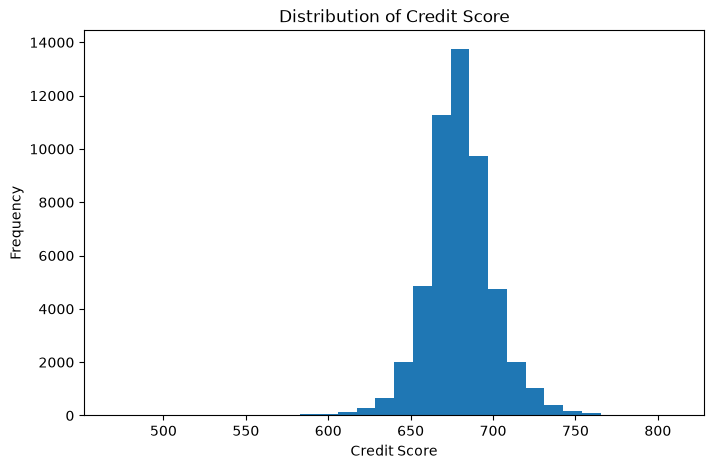

In [23]:
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    df["credit_score"].dropna(),
    bins=30
)

plt.xlabel(
    "Credit Score"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Credit Score"
)

plt.show()

C:\Users\Kamal\AppData\Local\Temp\ipykernel_21496\2719464886.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


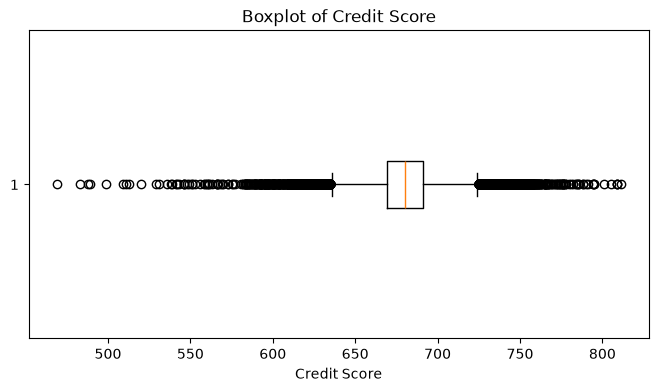

In [24]:
plt.figure(
    figsize=(8, 4)
)

plt.boxplot(
    df["credit_score"].dropna(),
    vert=False
)

plt.xlabel(
    "Credit Score"
)

plt.title(
    "Boxplot of Credit Score"
)

plt.show()

In [25]:
X = df.drop(
    columns=[
        "credit_score",
        "approved_flag",
        "prospectid"
    ],
    errors="ignore"
)

y = df["credit_score"]

In [26]:
print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (51336, 84)
y shape: (51336,)


In [27]:
numeric_features = (
    X.select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

In [28]:
categorical_features = (
    X.select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

In [29]:
print(
    "Number of numerical features:",
    len(numeric_features)
)

print(
    "Number of categorical features:",
    len(categorical_features)
)



Number of numerical features: 79
Number of categorical features: 5


In [30]:
print(
    categorical_features
)

['maritalstatus', 'education', 'gender', 'last_prod_enq2', 'first_prod_enq2']


In [31]:
eda_numeric = df.select_dtypes(
    include=np.number
)

In [32]:
credit_corr = (
    eda_numeric
    .corr()["credit_score"]
    .sort_values(
        ascending=False
    )
)

In [33]:
print(
    credit_corr.head(15)
)

credit_score           1.000000
num_std_12mts          0.470303
num_std                0.464193
num_std_6mts           0.441837
age                    0.272582
other_tl               0.258235
secured_tl             0.223383
tot_closed_tl          0.206652
total_tl               0.202859
pct_closed_tl          0.182756
time_with_curr_empr    0.176875
home_tl                0.168260
hl_flag                0.162458
gl_flag                0.149753
auto_tl                0.148962
Name: credit_score, dtype: float64


In [34]:
print(
    credit_corr.tail(15)
)

enq_l12m                       -0.125756
pct_opened_tls_l6m_of_l12m     -0.131621
max_deliq_6mts                 -0.151445
max_deliq_12mts                -0.154715
pct_of_active_tls_ever         -0.182756
pct_active_tl                  -0.182756
time_since_first_deliquency    -0.186691
max_delinquency_level          -0.186701
time_since_recent_deliquency   -0.186704
pct_cc_enq_l6m_of_l12m         -0.202295
pct_cc_enq_l6m_of_ever         -0.204150
pct_tl_open_l6m                -0.255157
pct_tl_open_l12m               -0.280756
pct_pl_enq_l6m_of_l12m         -0.378722
pct_pl_enq_l6m_of_ever         -0.387340
Name: credit_score, dtype: float64


In [35]:
eda_features = [
    "pct_tl_open_l6m",
    "pct_tl_closed_l6m",
    "pct_active_tl",
    "max_unsec_exposure_inpct"
]

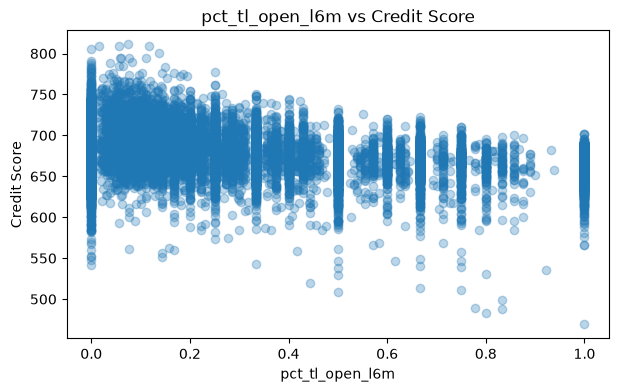

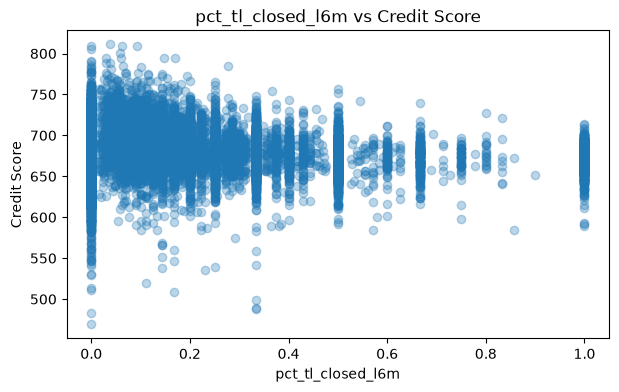

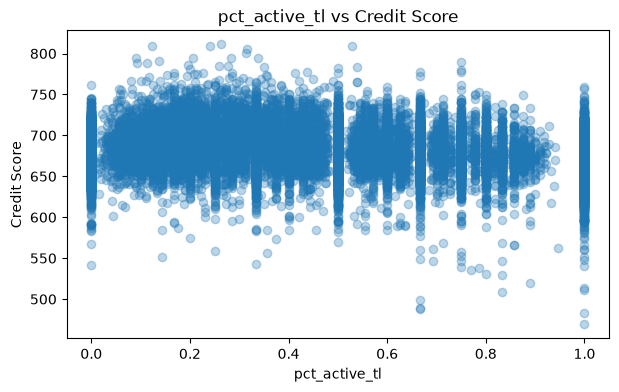

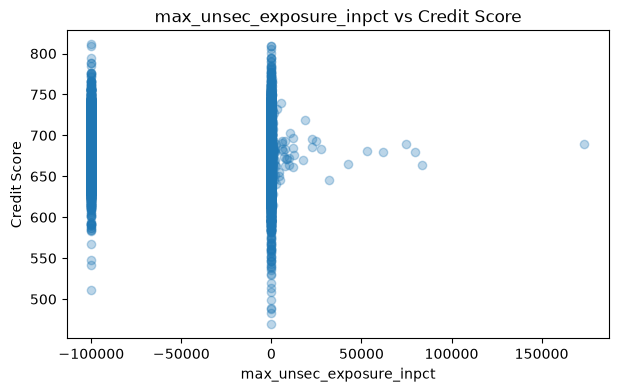

In [36]:
for col in eda_features:

    if col in df.columns:

        plt.figure(
            figsize=(7, 4)
        )

        plt.scatter(
            df[col],
            df["credit_score"],
            alpha=0.3
        )

        plt.xlabel(col)

        plt.ylabel(
            "Credit Score"
        )

        plt.title(
            f"{col} vs Credit Score"
        )

        plt.show()

In [37]:
for col in categorical_features:

    print(
        "\nColumn:",
        col
    )

    print(
        X[col]
        .value_counts(
            dropna=False
        )
        .head(10)
    )


Column: maritalstatus
maritalstatus
Married    37752
Single     13584
Name: count, dtype: int64

Column: education
education
GRADUATE          16673
12TH              14467
SSC                9276
UNDER GRADUATE     5492
OTHERS             2917
POST-GRADUATE      2242
PROFESSIONAL        269
Name: count, dtype: int64

Column: gender
gender
M    45245
F     6091
Name: count, dtype: int64

Column: last_prod_enq2
last_prod_enq2
others          20831
ConsumerLoan    17793
PL               7959
CC               2339
AL               1511
HL                903
Name: count, dtype: int64

Column: first_prod_enq2
first_prod_enq2
others          28120
ConsumerLoan    11860
PL               4889
AL               2870
CC               2188
HL               1409
Name: count, dtype: int64


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [39]:
print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "y_test:",
    y_test.shape
)

X_train: (41068, 84)
X_test: (10268, 84)
y_train: (41068,)
y_test: (10268,)


In [40]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

In [41]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),

        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [43]:
xgb_basic = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

In [44]:
xgb_basic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            xgb_basic
        )
    ]
)

In [45]:
xgb_basic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](84,)","['total_tl','tot_closed_tl','tot_active_tl',...,'gl_flag','last_prod_enq2', 'first_prod_enq2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,84
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through.

In [46]:
y_pred_basic = (
    xgb_basic_pipeline
    .predict(
        X_test
    )
)

In [47]:
r2_basic = r2_score(
    y_test,
    y_pred_basic
)

mae_basic = mean_absolute_error(
    y_test,
    y_pred_basic
)

mse_basic = mean_squared_error(
    y_test,
    y_pred_basic
)

rmse_basic = np.sqrt(
    mse_basic
)

print(
    "Basic XGBoost Regression"
)

print(
    "R2:",
    r2_basic
)

print(
    "MAE:",
    mae_basic
)

print(
    "MSE:",
    mse_basic
)

print(
    "RMSE:",
    rmse_basic
)

Basic XGBoost Regression
R2: 0.9020381569862366
MAE: 5.465428829193115
MSE: 40.976749420166016
RMSE: 6.401308414704451


In [48]:
y_train_pred_basic = (
    xgb_basic_pipeline
    .predict(
        X_train
    )
)

train_r2_basic = r2_score(
    y_train,
    y_train_pred_basic
)

print(
    "Training R2:",
    train_r2_basic
)

print(
    "Testing R2:",
    r2_basic
)

Training R2: 0.9231901168823242
Testing R2: 0.9020381569862366


In [49]:
xgb_regularized = XGBRegressor(

    objective="reg:squarederror",

    n_estimators=300,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=3,

    gamma=0.1,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=0.1,

    reg_lambda=1.0,

    random_state=42,

    n_jobs=-1
)

In [50]:
xgb_reg_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            xgb_regularized
        )
    ]
)

In [51]:
xgb_reg_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](84,)","['total_tl','tot_closed_tl','tot_active_tl',...,'gl_flag','last_prod_enq2', 'first_prod_enq2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,84
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through.

In [52]:
y_pred_reg = (
    xgb_reg_pipeline
    .predict(
        X_test
    )
)

In [53]:
r2_reg = r2_score(
    y_test,
    y_pred_reg
)

mae_reg = mean_absolute_error(
    y_test,
    y_pred_reg
)

mse_reg = mean_squared_error(
    y_test,
    y_pred_reg
)

rmse_reg = np.sqrt(
    mse_reg
)

print(
    "Regularized XGBoost"
)

print(
    "R2:",
    r2_reg
)

print(
    "MAE:",
    mae_reg
)

print(
    "MSE:",
    mse_reg
)

print(
    "RMSE:",
    rmse_reg
)

Regularized XGBoost
R2: 0.9043136835098267
MAE: 5.441453456878662
MSE: 40.0249137878418
RMSE: 6.326524621610336


In [54]:
comparison = pd.DataFrame(
    {
        "Model": [
            "Basic XGBoost",
            "Regularized XGBoost"
        ],

        "R2": [
            r2_basic,
            r2_reg
        ],

        "MAE": [
            mae_basic,
            mae_reg
        ],

        "MSE": [
            mse_basic,
            mse_reg
        ],

        "RMSE": [
            rmse_basic,
            rmse_reg
        ]
    }
)

comparison

,Model,R2,MAE,MSE,RMSE
0,Basic XGBoost,0.902038,5.465429,40.976749,6.401308
1,Regularized XGBoost,0.904314,5.441453,40.024914,6.326525


In [55]:
#Check overfitting after regularization
y_train_pred_reg = (
    xgb_reg_pipeline
    .predict(
        X_train
    )
)

train_r2_reg = r2_score(
    y_train,
    y_train_pred_reg
)

print(
    "Basic XGBoost"
)

print(
    "Train R2:",
    train_r2_basic
)

print(
    "Test R2:",
    r2_basic
)

print()

print(
    "Regularized XGBoost"
)

print(
    "Train R2:",
    train_r2_reg
)

print(
    "Test R2:",
    r2_reg
)

Basic XGBoost
Train R2: 0.9231901168823242
Test R2: 0.9020381569862366

Regularized XGBoost
Train R2: 0.9175621271133423
Test R2: 0.9043136835098267


In [56]:
print(
    "Basic Train-Test Gap:",
    train_r2_basic - r2_basic
)

print(
    "Regularized Train-Test Gap:",
    train_r2_reg - r2_reg
)

Basic Train-Test Gap: 0.021151959896087646
Regularized Train-Test Gap: 0.013248443603515625


What exactly is regularization here?

The most important parameters are:

reg_alpha=0.1

which adds L1 regularization, and:

reg_lambda=1.0

which adds L2 regularization.

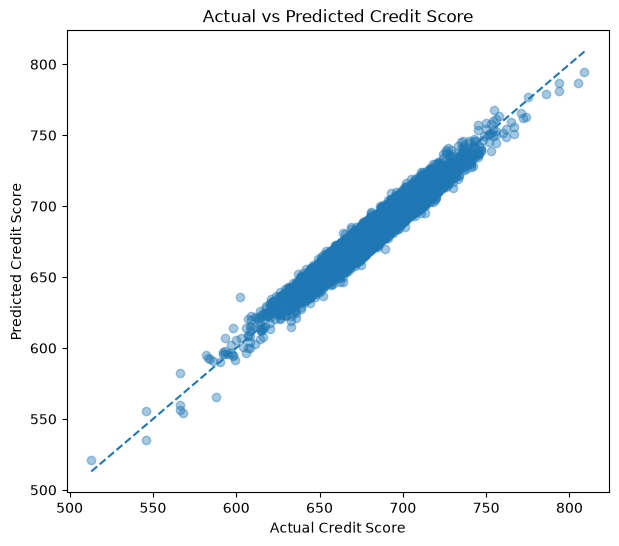

In [57]:
#Actual vs Predicted Plot
plt.figure(
    figsize=(7, 6)
)

plt.scatter(
    y_test,
    y_pred_reg,
    alpha=0.4
)

minimum = min(
    y_test.min(),
    y_pred_reg.min()
)

maximum = max(
    y_test.max(),
    y_pred_reg.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual Credit Score"
)

plt.ylabel(
    "Predicted Credit Score"
)

plt.title(
    "Actual vs Predicted Credit Score"
)

plt.show()

The diagonal line represents:

 Actual = Predicted 

Points closer to that line indicate better predictions.

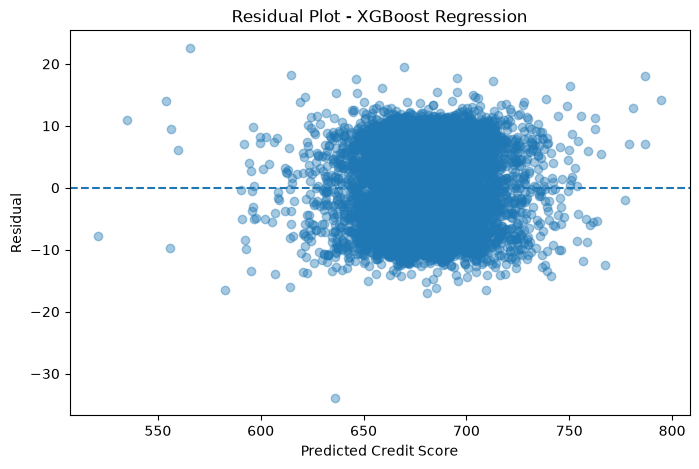

In [59]:
#Residual Analysis
#Residual:
# Residual = Actual-Predicted $$
#Calculate:

residuals = (
    y_test -
    y_pred_reg
)


plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    y_pred_reg,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Credit Score"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residual Plot - XGBoost Regression"
)

plt.show()

In [60]:
#Feature Importance
#First get the fitted preprocessor:

fitted_preprocessor = (
    xgb_reg_pipeline
    .named_steps[
        "preprocessor"
    ]
)

In [61]:
#Get transformed feature names:

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

In [62]:
#Get XGBoost model:

fitted_xgb = (
    xgb_reg_pipeline
    .named_steps[
        "model"
    ]
)

In [63]:
#Importance:

importance = (
    fitted_xgb
    .feature_importances_
)

In [64]:
feature_importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": importance
    }
)

In [65]:
feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.head(15)

,Feature,Importance
61,num__enq_l3m,0.174221
74,num__pct_pl_enq_l6m_of_ever,0.114106
23,num__age_oldest_tl,0.108299
40,num__num_std_12mts,0.091904
60,num__enq_l6m,0.066487
38,num__num_std,0.053498
72,num__pct_pl_enq_l6m_of_l12m,0.047661
26,num__time_since_first_deliquency,0.042247
27,num__time_since_recent_deliquency,0.039170
28,num__num_times_delinquent,0.024065


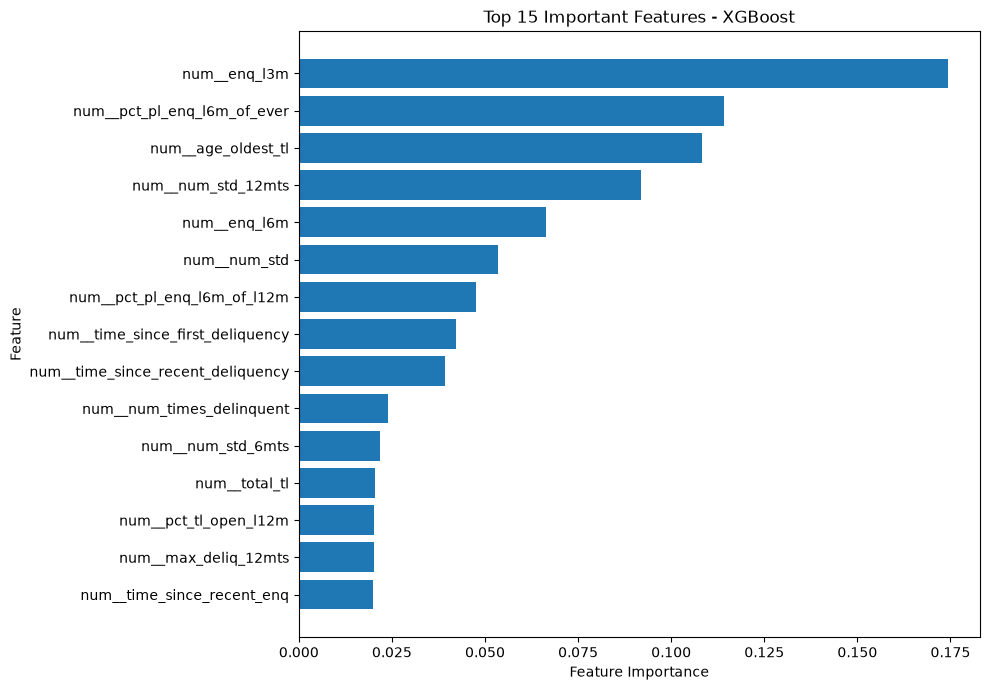

In [66]:
top_features = (
    feature_importance
    .head(15)
    .sort_values(
        "Importance"
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 15 Important Features - XGBoost"
)

plt.tight_layout()

plt.show()

In [67]:
final_comparison = pd.DataFrame(
    {
        "Model": [
            "Basic XGBoost",
            "Regularized XGBoost"
        ],

        "Train R2": [
            train_r2_basic,
            train_r2_reg
        ],

        "Test R2": [
            r2_basic,
            r2_reg
        ],

        "Train-Test Gap": [
            train_r2_basic - r2_basic,
            train_r2_reg - r2_reg
        ],

        "MAE": [
            mae_basic,
            mae_reg
        ],

        "MSE": [
            mse_basic,
            mse_reg
        ],

        "RMSE": [
            rmse_basic,
            rmse_reg
        ]
    }
)

final_comparison

,Model,Train R2,Test R2,Train-Test Gap,MAE,MSE,RMSE
0,Basic XGBoost,0.923190,0.902038,0.021152,5.465429,40.976749,6.401308
1,Regularized XGBoost,0.917562,0.904314,0.013248,5.441453,40.024914,6.326525


We used XGBoost Regression because credit_score is a continuous numerical target. 
After cleaning the CIBIL dataset, we removed identifiers and possible leakage variables, handled missing numerical values
using median imputation and categorical values using mode imputation, and converted categorical variables using one-hot encoding.
XGBoost builds decision trees sequentially, where each new tree attempts to correct errors made by previous trees.
We then applied regularization using reg_alpha, reg_lambda, max_depth, gamma, min_child_weight, subsample, and colsample_bytree to control complexity and reduce overfitting. 
Finally, we evaluated the model using R², MAE, MSE, RMSE, the train-test gap, residual analysis, and feature importance.

One particularly important point for this experiment:we did not add StandardScaler ... XGBoost is tree-based and does not normally require feature scaling.